# Customer Segmentation — Mall Customers Dataset
**Dataset:** 200 customers | 5 features: CustomerID, Gender, Age, Annual Income, Spending Score

## Step 1 — Install Libraries
Run once. Wait for it to finish before moving on.

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 — Import Libraries

In [12]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")
import os
os.makedirs("../images", exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")
print("All libraries loaded!")

All libraries loaded!


## Step 3 — Load the Dataset
> Make sure `Mall_Customers.csv` is inside your `data/` folder.

In [6]:
import pandas as pd
df = pd.read_csv(r"C:\Users\dell\OneDrive\Desktop\Customer-Segmentation-Project\data\Mall_Customers.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(10)

Shape: (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## Step 4 — Explore the Data

In [7]:
# Basic statistics
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
# Check nulls and data types
print("Missing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Data types:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [9]:
# Gender distribution
print("Gender counts:")
print(df["Gender"].value_counts())

Gender counts:
Gender
Female    112
Male       88
Name: count, dtype: int64


## Step 5 — Visualize Raw Data Distributions

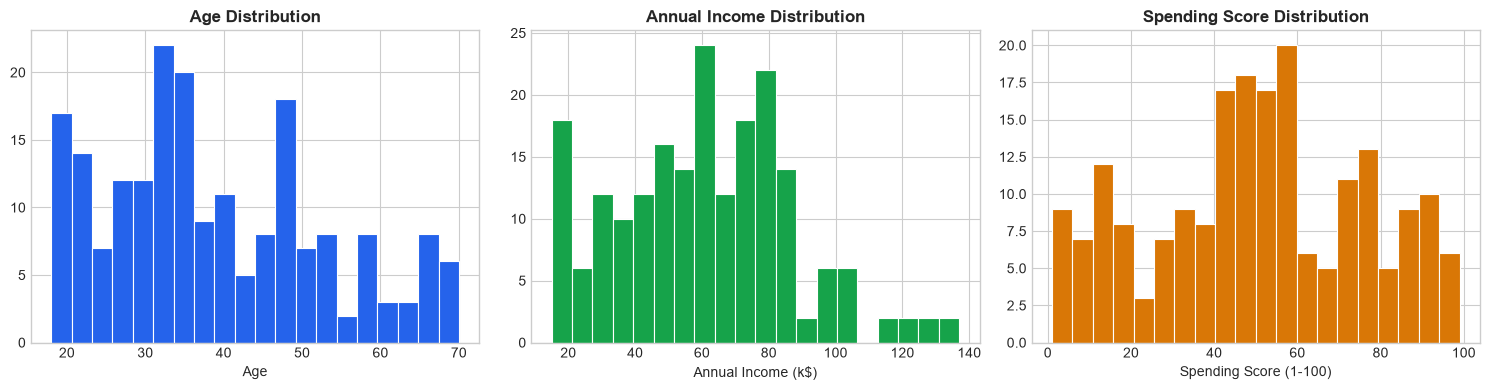

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["Age"], bins=20, color="#2563EB", edgecolor="white", linewidth=0.8)
axes[0].set_title("Age Distribution", fontweight="bold")
axes[0].set_xlabel("Age")

axes[1].hist(df["Annual Income (k$)"], bins=20, color="#16A34A", edgecolor="white", linewidth=0.8)
axes[1].set_title("Annual Income Distribution", fontweight="bold")
axes[1].set_xlabel("Annual Income (k$)")

axes[2].hist(df["Spending Score (1-100)"], bins=20, color="#D97706", edgecolor="white", linewidth=0.8)
axes[2].set_title("Spending Score Distribution", fontweight="bold")
axes[2].set_xlabel("Spending Score (1-100)")

plt.tight_layout()

plt.show()

## Step 6 — Correlation Heatmap

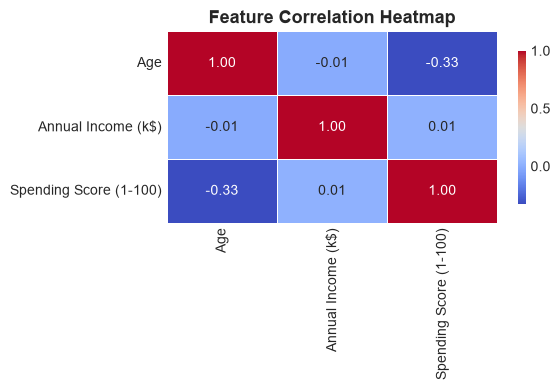

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
corr = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../images/2_correlation.png", dpi=150)
plt.show()

## Step 7 — Prepare Features for Clustering
We use Annual Income and Spending Score — the two most important features for customer segmentation.

In [15]:
# Select the 2 key features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Scaled mean (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Scaled std  (should be ~1):", X_scaled.std(axis=0).round(3))

Feature matrix shape: (200, 2)
Scaled mean (should be ~0): [-0. -0.]
Scaled std  (should be ~1): [1. 1.]


## Step 8 — Find Optimal K (Elbow + Silhouette)
These two methods together help us pick the best number of clusters.

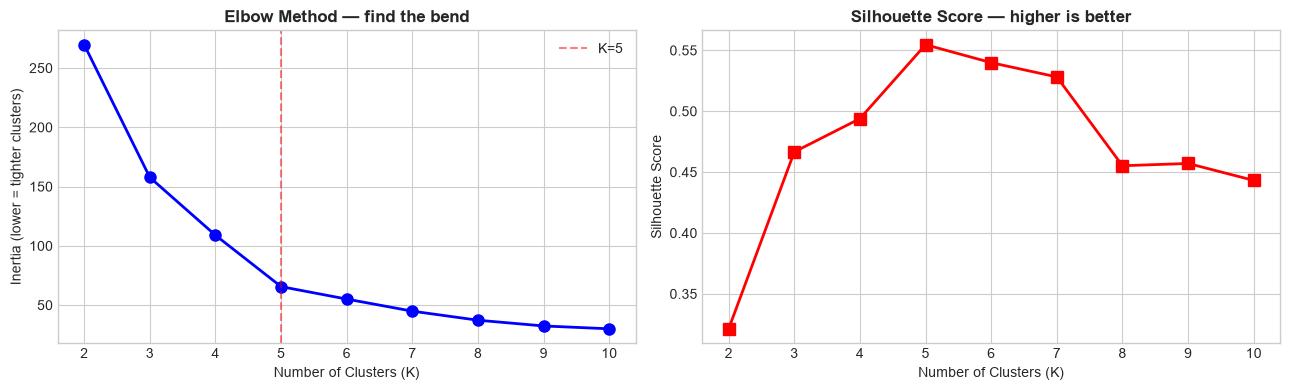

Best K by Silhouette: 5


In [16]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_title("Elbow Method — find the bend", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (lower = tighter clusters)")
axes[0].axvline(x=5, color="red", linestyle="--", alpha=0.5, label="K=5")
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, "rs-", linewidth=2, markersize=8)
axes[1].set_title("Silhouette Score — higher is better", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("../images/3_elbow_silhouette.png", dpi=150)
plt.show()

best_k = list(K_range)[silhouettes.index(max(silhouettes))]
print(f"Best K by Silhouette: {best_k}")

## Step 9 — Apply KMeans with K=5
The Mall Customers dataset is a classic — K=5 gives the well-known 5 customer segments.

In [17]:
BEST_K = 5

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Customers per cluster:")
print(df["Cluster"].value_counts().sort_index())

Customers per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## Step 10 — Label the Clusters
Based on Income vs Spending patterns, we assign meaningful names.

In [18]:
# Get cluster centers in original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=["Income_Center", "Score_Center"])
print("Cluster Centers (original scale):")
print(centers_df.round(1))

# Label based on income & spending score
def label_cluster(row):
    inc = row["Income_Center"]
    scr = row["Score_Center"]
    if inc >= 60 and scr >= 60:
        return "High Income, High Spenders"
    elif inc >= 60 and scr < 40:
        return "High Income, Low Spenders"
    elif inc < 40 and scr >= 60:
        return "Low Income, High Spenders"
    elif inc < 40 and scr < 40:
        return "Low Income, Low Spenders"
    else:
        return "Average Customers"

centers_df["Label"] = centers_df.apply(label_cluster, axis=1)
label_map = centers_df["Label"].to_dict()
df["Segment"] = df["Cluster"].map(label_map)

print("\nSegment distribution:")
print(df["Segment"].value_counts())

Cluster Centers (original scale):
   Income_Center  Score_Center
0           55.3          49.5
1           86.5          82.1
2           25.7          79.4
3           88.2          17.1
4           26.3          20.9

Segment distribution:
Segment
Average Customers             81
High Income, High Spenders    39
High Income, Low Spenders     35
Low Income, Low Spenders      23
Low Income, High Spenders     22
Name: count, dtype: int64


## Step 11 — Chart: Income vs Spending Score (Main Cluster Plot)

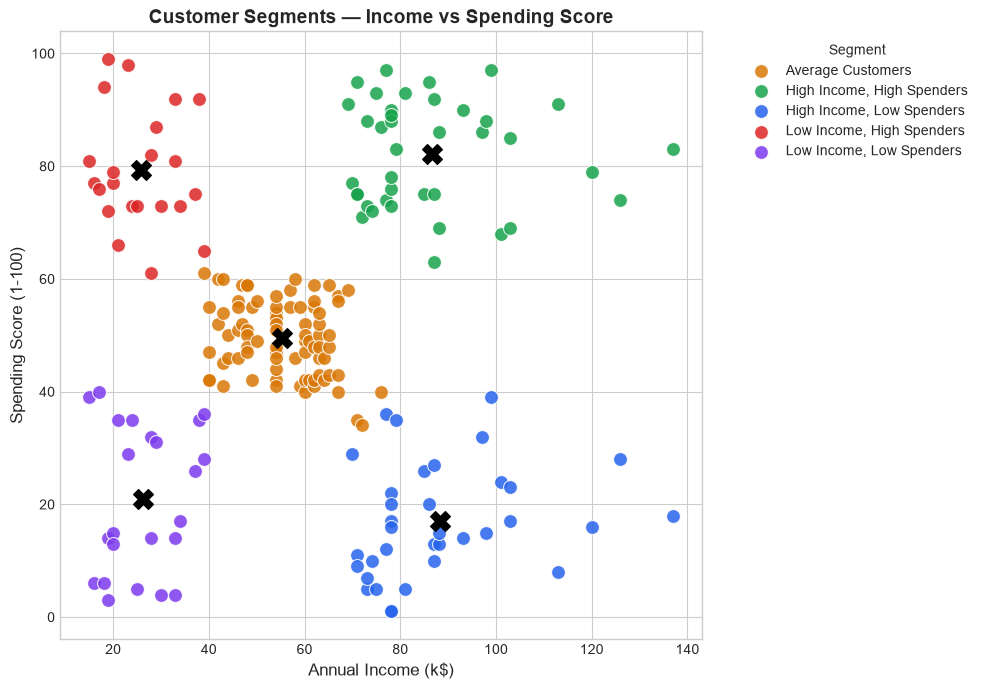

In [19]:
COLORS = {
    "High Income, High Spenders":  "#16A34A",
    "High Income, Low Spenders":   "#2563EB",
    "Low Income, High Spenders":   "#DC2626",
    "Low Income, Low Spenders":    "#7C3AED",
    "Average Customers":           "#D97706"
}

fig, ax = plt.subplots(figsize=(10, 7))

for seg, grp in df.groupby("Segment"):
    ax.scatter(grp["Annual Income (k$)"], grp["Spending Score (1-100)"],
               label=seg, color=COLORS.get(seg, "#888"),
               s=100, alpha=0.85, edgecolors="white", linewidth=0.8)

# Plot cluster centers
for _, row in centers_df.iterrows():
    ax.scatter(row["Income_Center"], row["Score_Center"],
               color="black", s=200, marker="X", zorder=5)

ax.set_title("Customer Segments — Income vs Spending Score", fontsize=14, fontweight="bold")
ax.set_xlabel("Annual Income (k$)", fontsize=12)
ax.set_ylabel("Spending Score (1-100)", fontsize=12)
ax.legend(title="Segment", bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.savefig("../images/4_clusters_income_spending.png", dpi=150)
plt.show()

## Step 12 — Chart: Age vs Spending Score

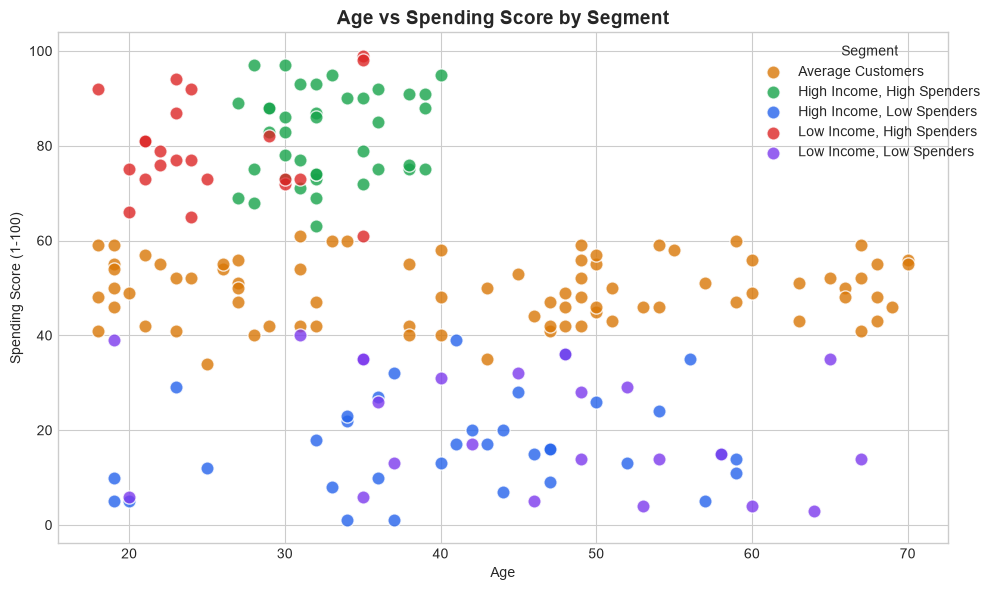

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
for seg, grp in df.groupby("Segment"):
    ax.scatter(grp["Age"], grp["Spending Score (1-100)"],
               label=seg, color=COLORS.get(seg, "#888"),
               s=90, alpha=0.8, edgecolors="white")
ax.set_title("Age vs Spending Score by Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Spending Score (1-100)")
ax.legend(title="Segment", bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.savefig("../images/5_age_vs_spending.png", dpi=150)
plt.show()

## Step 13 — Chart: Gender Distribution per Segment

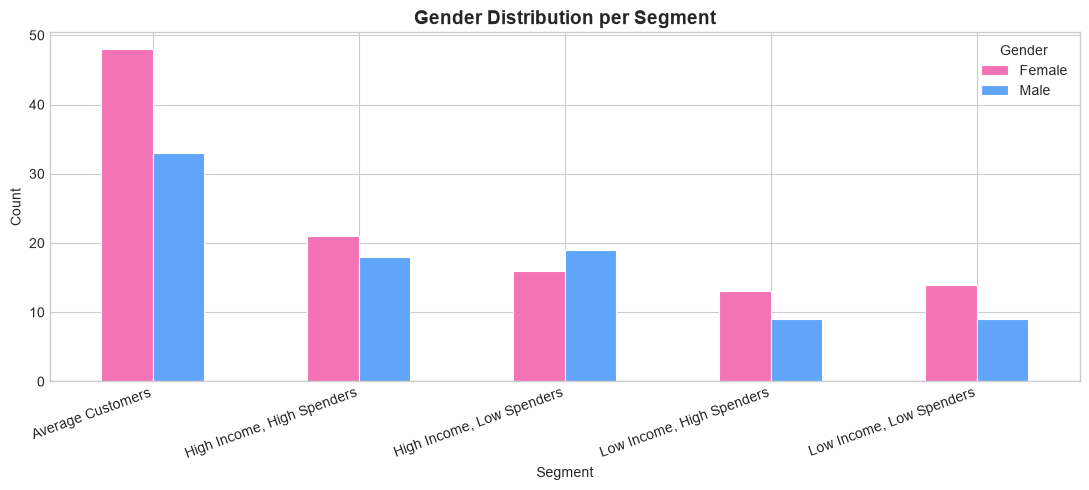

In [21]:
gender_seg = df.groupby(["Segment", "Gender"]).size().unstack(fill_value=0)
gender_seg.plot(kind="bar", figsize=(11, 5), color=["#F472B6","#60A5FA"],
                edgecolor="white", linewidth=0.8)
plt.title("Gender Distribution per Segment", fontsize=14, fontweight="bold")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Gender")
plt.tight_layout()
plt.savefig("../images/6_gender_per_segment.png", dpi=150)
plt.show()

## Step 14 — Chart: Segment Size (Bar Chart)

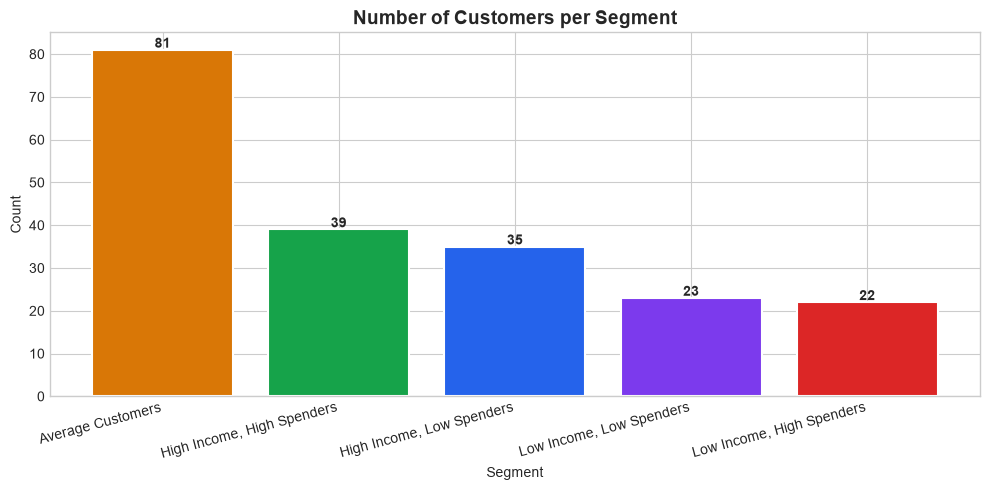

In [22]:
counts = df["Segment"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS.get(s, "#888") for s in counts.index],
              edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", fontweight="bold")
ax.set_title("Number of Customers per Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Segment")
ax.set_ylabel("Count")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("../images/7_segment_sizes.png", dpi=150)
plt.show()

## Step 15 — Segment Summary Table

In [23]:
summary = df.groupby("Segment").agg(
    Count            = ("CustomerID", "count"),
    Avg_Age          = ("Age", "mean"),
    Avg_Income       = ("Annual Income (k$)", "mean"),
    Avg_Spend_Score  = ("Spending Score (1-100)", "mean")
).round(1)

print("=== Segment Summary ===")
print(summary)

=== Segment Summary ===
                            Count  Avg_Age  Avg_Income  Avg_Spend_Score
Segment                                                                
Average Customers              81     42.7        55.3             49.5
High Income, High Spenders     39     32.7        86.5             82.1
High Income, Low Spenders      35     41.1        88.2             17.1
Low Income, High Spenders      22     25.3        25.7             79.4
Low Income, Low Spenders       23     45.2        26.3             20.9


## Step 16 — Save Results & Business Insights

In [25]:
import os
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/segmentation_results.csv", index=False)
print("segmentation_results.csv saved in data/ folder!")

print("\n=== Business Insights ===")
insights = {
    "High Income, High Spenders":  "VIP customers — offer loyalty rewards and premium products.",
    "High Income, Low Spenders":   "Cautious spenders — target with trust-building campaigns and quality messaging.",
    "Low Income, High Spenders":   "Impulsive buyers — offer EMI options, deals, and limited-time offers.",
    "Low Income, Low Spenders":    "Budget customers — engage with heavy discounts and value packs.",
    "Average Customers":           "Middle segment — biggest group, respond well to seasonal sales."
}
for seg, tip in insights.items():
    sub = df[df["Segment"] == seg]
    if len(sub) > 0:
        print(f"\n{seg} ({len(sub)} customers)")
        print(f"  Avg Income: ${sub['Annual Income (k$)'].mean():.0f}k  |  Avg Score: {sub['Spending Score (1-100)'].mean():.0f}")
        print(f"  Strategy: {tip}")

segmentation_results.csv saved in data/ folder!

=== Business Insights ===

High Income, High Spenders (39 customers)
  Avg Income: $87k  |  Avg Score: 82
  Strategy: VIP customers — offer loyalty rewards and premium products.

High Income, Low Spenders (35 customers)
  Avg Income: $88k  |  Avg Score: 17
  Strategy: Cautious spenders — target with trust-building campaigns and quality messaging.

Low Income, High Spenders (22 customers)
  Avg Income: $26k  |  Avg Score: 79
  Strategy: Impulsive buyers — offer EMI options, deals, and limited-time offers.

Low Income, Low Spenders (23 customers)
  Avg Income: $26k  |  Avg Score: 21
  Strategy: Budget customers — engage with heavy discounts and value packs.

Average Customers (81 customers)
  Avg Income: $55k  |  Avg Score: 50
  Strategy: Middle segment — biggest group, respond well to seasonal sales.
